# Week 10 Lab — Practical Deep Learning: Augmentation, Dropout & Batch Normalization (Solutions)

---

**What you will build:**
- A cats-vs-dogs binary classifier using CIFAR-10
- Observe overfitting on a baseline model
- Fix it with data augmentation, Dropout, and Batch Normalization
- Compare training curves across all four models

---
# Part 1 — Setup and Data Loading

## Step 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

## Step 2 — Load CIFAR-10 and Extract Cats & Dogs

In [2]:
# Load CIFAR-10
(x_train_all, y_train_all), (x_test_all, y_test_all) = cifar10.load_data()

CAT_LABEL = 3
DOG_LABEL = 5

# Extract cats and dogs from training set
train_mask = np.isin(y_train_all.flatten(), [CAT_LABEL, DOG_LABEL])
x_train = x_train_all[train_mask]
y_train_raw = y_train_all[train_mask].flatten()

# Extract cats and dogs from test set
test_mask = np.isin(y_test_all.flatten(), [CAT_LABEL, DOG_LABEL])
x_test = x_test_all[test_mask]
y_test_raw = y_test_all[test_mask].flatten()

# Convert labels to binary: cat=0, dog=1
y_train = (y_train_raw == DOG_LABEL).astype('float32')
y_test  = (y_test_raw  == DOG_LABEL).astype('float32')

print("Training set:", x_train.shape, "| Labels:", y_train.shape)
print("Test set:    ", x_test.shape,  "| Labels:", y_test.shape)
print(f"Cats in train: {np.sum(y_train==0)}, Dogs in train: {np.sum(y_train==1)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


c:\Users\Tess\miniforge3\envs\deep-learning\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training set: (10000, 32, 32, 3) | Labels: (10000,)
Test set:     (2000, 32, 32, 3) | Labels: (2000,)
Cats in train: 5000, Dogs in train: 5000


## Step 3 — Normalize Pixel Values and Visualize

In [3]:
# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

print("Pixel range — min:", x_train.min(), "max:", x_train.max())

Pixel range — min: 0.0 max: 1.0


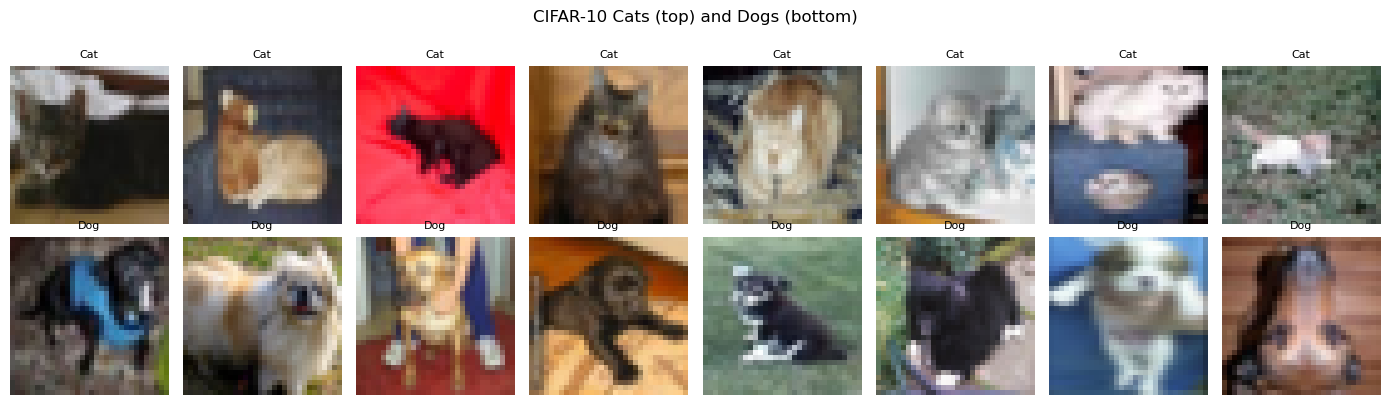

In [4]:
# Visualize some training images
class_names = ['Cat', 'Dog']
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for row, label in enumerate([0, 1]):
    imgs = x_train[y_train == label][:8]
    for col, img in enumerate(imgs):
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_names[label], fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('CIFAR-10 Cats (top) and Dogs (bottom)', y=1.01)
plt.tight_layout()
plt.show()

---
# Part 2 — Baseline CNN (No Augmentation, No Regularization)

## Step 4 — Build the Baseline CNN

In [5]:
def build_baseline_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

c:\Users\Tess\miniforge3\envs\deep-learning\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,561 (1.20 MB)

 Trainable params: 314,561 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Compile and Train the Baseline Model

In [6]:
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5895 - loss: 0.6638 - val_accuracy: 0.6245 - val_loss: 0.6523
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6736 - loss: 0.5993 - val_accuracy: 0.7000 - val_loss: 0.5723
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7053 - loss: 0.5667 - val_accuracy: 0.7030 - val_loss: 0.5674
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7264 - loss: 0.5349 - val_accuracy: 0.7250 - val_loss: 0.5399
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7520 - loss: 0.5061 - val_accuracy: 0.7265 - val_loss: 0.5388
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7620 - loss: 0.4865 - val_accuracy: 0.7355 - val_loss: 0.5146
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7786 - loss: 0.4558 - val_accuracy: 0.7550 - val_loss: 0.5076
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8005 - loss: 0.4287 - val_accura

## Step 6 — Plot Training Curves and Observe Overfitting

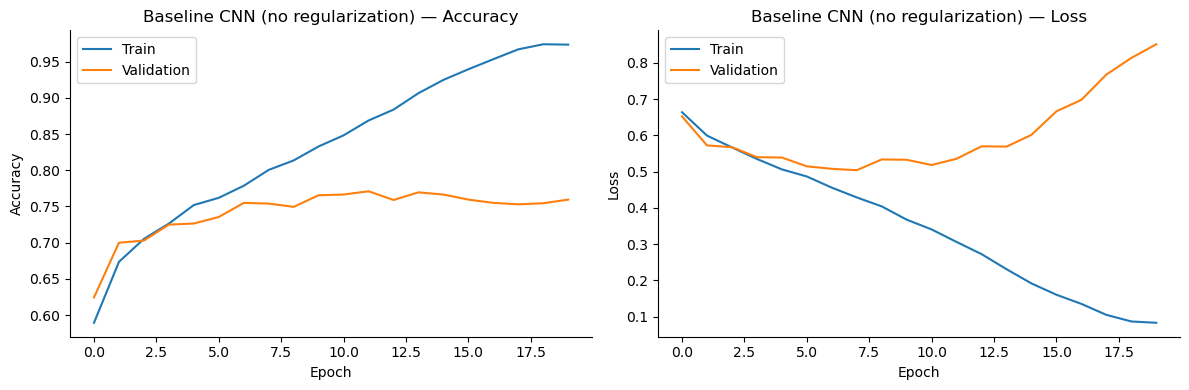

In [7]:
def plot_history(history, title='Training Curves'):
    """Plot training and validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(title + ' — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
    
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(title + ' — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

plot_history(history_baseline, 'Baseline CNN (no regularization)')

**Answer**: Yes, overfitting is clearly visible. Training accuracy climbs toward ~80–85% while validation accuracy plateaus or drops around epoch 10–15. The gap between them is the signature of overfitting — the model is memorizing training data rather than learning generalizable features.

---
# Part 3 — Data Augmentation

## Step 7 — Visualize Augmented Cat Images

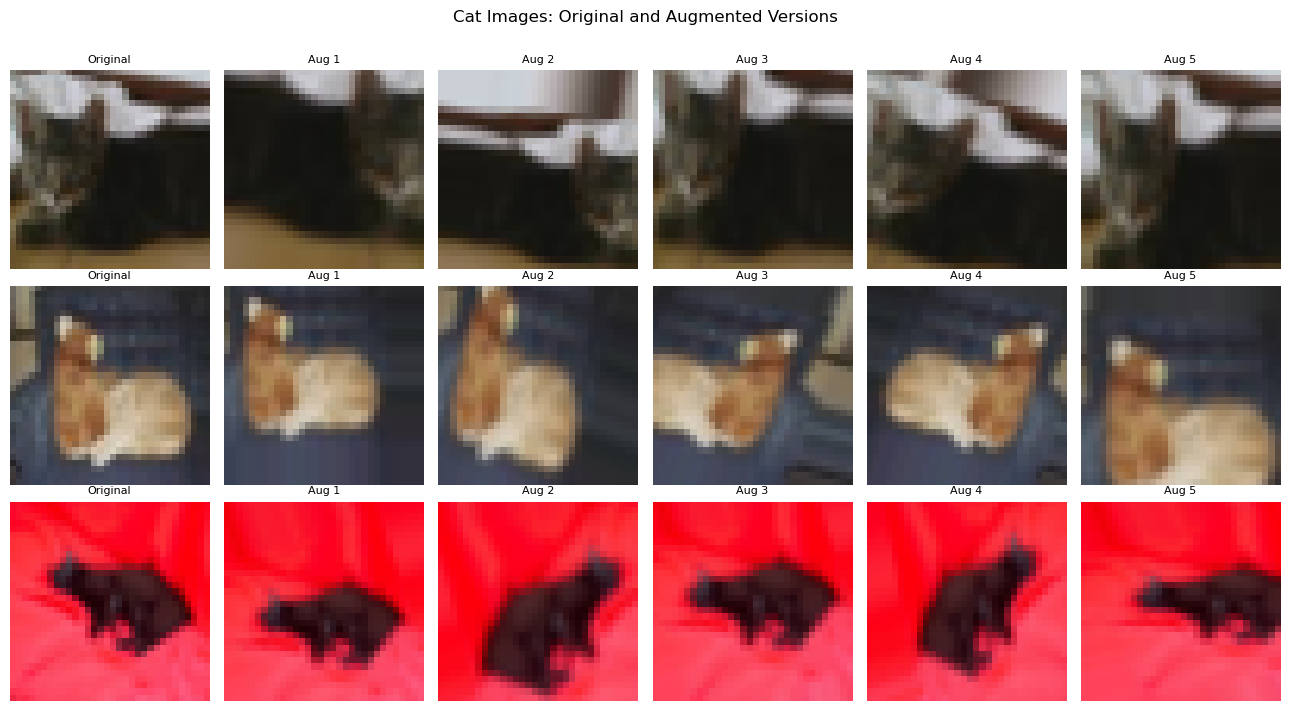

In [8]:
aug_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

cat_images = x_train[y_train == 0][:3]

fig, axes = plt.subplots(3, 6, figsize=(13, 7))
for row, cat in enumerate(cat_images):
    axes[row, 0].imshow(cat)
    axes[row, 0].set_title('Original', fontsize=8)
    axes[row, 0].axis('off')
    img_batch = cat.reshape((1,) + cat.shape)
    for col, batch in zip(range(1, 6), aug_datagen.flow(img_batch, batch_size=1)):
        axes[row, col].imshow(np.clip(batch[0], 0, 1))
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('Cat Images: Original and Augmented Versions', y=1.01)
plt.tight_layout()
plt.show()

## Step 8 — Train the Same Model with Augmentation

Epoch 1/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.5652 - loss: 0.6803 - val_accuracy: 0.6170 - val_loss: 0.6473
Epoch 2/20
  1/156 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5781 - loss: 0.6834

c:\Users\Tess\miniforge3\envs\deep-learning\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5781 - loss: 0.6834 - val_accuracy: 0.6045 - val_loss: 0.6488
Epoch 3/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.6074 - loss: 0.6553 - val_accuracy: 0.6605 - val_loss: 0.6153
Epoch 4/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6094 - loss: 0.6674 - val_accuracy: 0.6655 - val_loss: 0.6161
Epoch 5/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6322 - loss: 0.6378 - val_accuracy: 0.7010 - val_loss: 0.5729
Epoch 6/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6562 - loss: 0.5809 - val_accuracy: 0.7000 - val_loss: 0.5741
Epoch 7/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6648 - loss: 0.6124 - val_accuracy: 0.6860 - val_loss: 0.5738
Epoch 8/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6719 - loss: 0.5850 - val_accuracy: 0.7105 - val_loss: 0.5524
Epoch 9/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.6744 - loss: 0.6013 - val_accuracy: 0.7205 - 

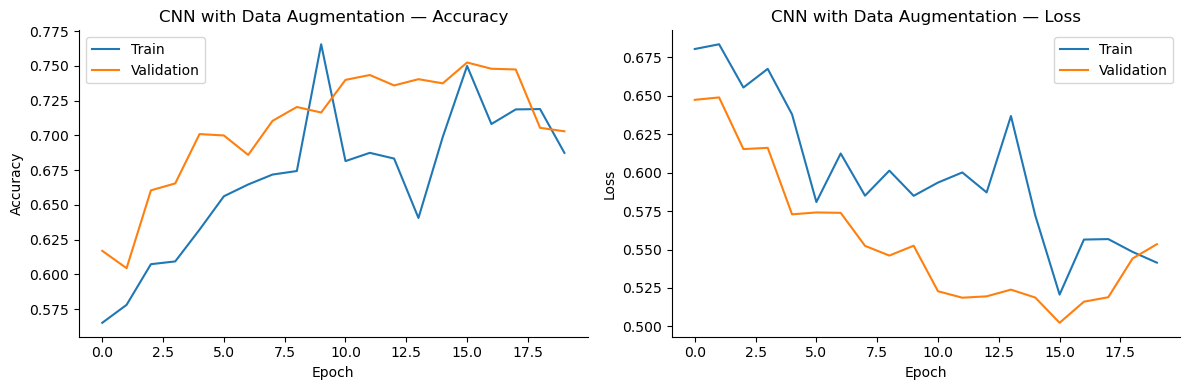

In [9]:
aug_model = build_baseline_model()
aug_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

train_gen = aug_datagen.flow(x_train, y_train, batch_size=64)

history_aug = aug_model.fit(
    train_gen,
    steps_per_epoch=len(x_train) // 64,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

plot_history(history_aug, 'CNN with Data Augmentation')

**Answer**: Augmentation reduces overfitting by making the model see more varied versions of each image. Training accuracy grows more slowly (the problem is harder) while validation accuracy is more stable. The train/val gap is smaller than the baseline.

---
# Part 4 — Adding Dropout

## Step 9 — Build a Model with Dropout

In [10]:
def build_dropout_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

dropout_model = build_dropout_model()
dropout_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,561 (1.20 MB)

 Trainable params: 314,561 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Step 10 — Train with Augmentation + Dropout

Epoch 1/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5447 - loss: 0.6876 - val_accuracy: 0.5650 - val_loss: 0.6711
Epoch 2/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5781 - loss: 0.6753 - val_accuracy: 0.5735 - val_loss: 0.6692
Epoch 3/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5850 - loss: 0.6713 - val_accuracy: 0.6615 - val_loss: 0.6383
Epoch 4/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5938 - loss: 0.6417 - val_accuracy: 0.6535 - val_loss: 0.6405
Epoch 5/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.6112 - loss: 0.6552 - val_accuracy: 0.6635 - val_loss: 0.6217
Epoch 6/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6094 - loss: 0.6500 - val_accuracy: 0.6535 - val_loss: 0.6221
Epoch 7/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6407 - loss: 0.6390 - val_accuracy: 0.6570 - val_loss: 0.6197
Epoch 8/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6719 - loss: 0.6397 - val_accuracy

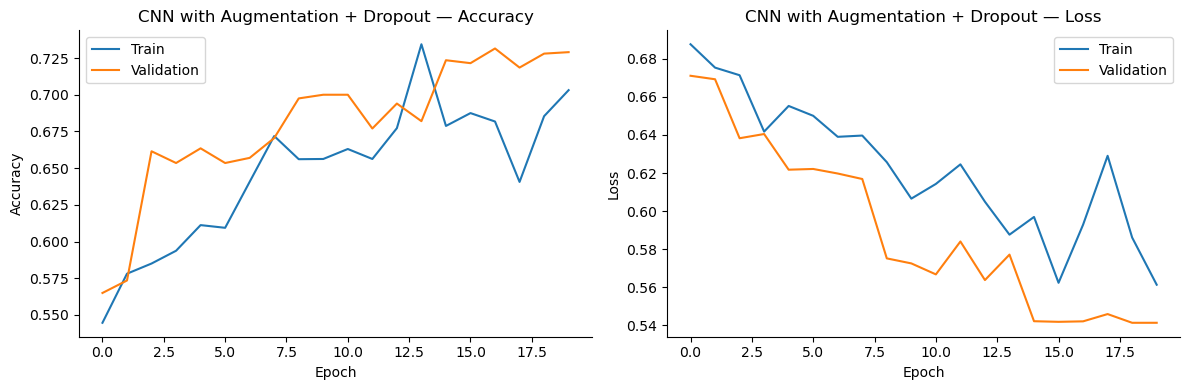

In [11]:
dropout_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

train_gen2 = aug_datagen.flow(x_train, y_train, batch_size=64)
history_dropout = dropout_model.fit(
    train_gen2,
    steps_per_epoch=len(x_train) // 64,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

plot_history(history_dropout, 'CNN with Augmentation + Dropout')

---
# Part 5 — Adding Batch Normalization

## Step 11 — Build a Model with Batch Normalization + Dropout

In [12]:
def build_bn_model():
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), input_shape=(32,32,3)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(2,2),

        # Block 2
        Conv2D(64, (3,3)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Dense head
        Flatten(),
        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

bn_model = build_bn_model()
bn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,457 (1.20 MB)

 Trainable params: 315,009 (1.20 MB)

 Non-trainable params: 448 (1.75 KB)

## Step 12 — Train with Augmentation + BatchNorm + Dropout

Epoch 1/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5673 - loss: 0.7621 - val_accuracy: 0.5285 - val_loss: 0.7012
Epoch 2/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6094 - loss: 0.6964 - val_accuracy: 0.5285 - val_loss: 0.7014
Epoch 3/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6158 - loss: 0.6711 - val_accuracy: 0.6415 - val_loss: 0.6413
Epoch 4/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6562 - loss: 0.5553 - val_accuracy: 0.6370 - val_loss: 0.6397
Epoch 5/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6513 - loss: 0.6287 - val_accuracy: 0.6670 - val_loss: 0.5916
Epoch 6/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6719 - loss: 0.6063 - val_accuracy: 0.6605 - val_loss: 0.5970
Epoch 7/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6627 - loss: 0.6154 - val_accuracy: 0.7035 - val_loss: 0.5884
Epoch 8/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.5991 - val_accurac

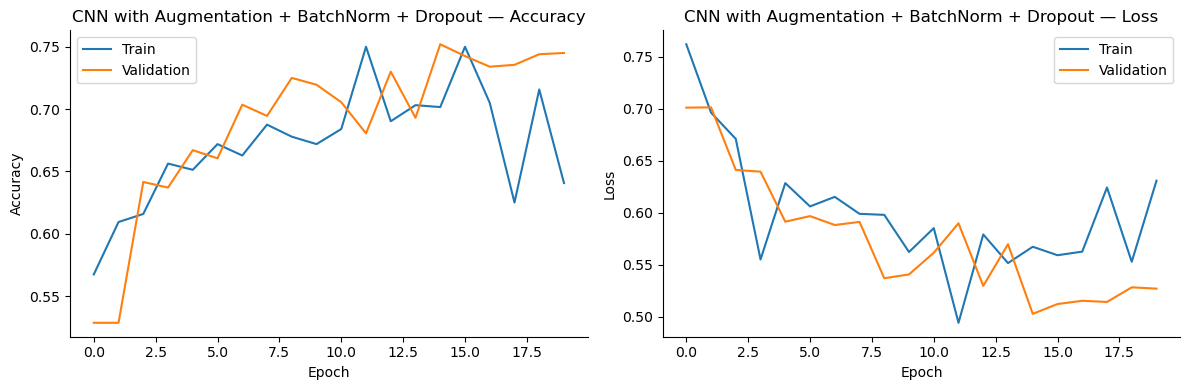

In [13]:
bn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

train_gen3 = aug_datagen.flow(x_train, y_train, batch_size=64)
history_bn = bn_model.fit(
    train_gen3,
    steps_per_epoch=len(x_train) // 64,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

plot_history(history_bn, 'CNN with Augmentation + BatchNorm + Dropout')

---
# Part 6 — Compare All Models

## Step 13 — Side-by-Side Validation Accuracy Comparison

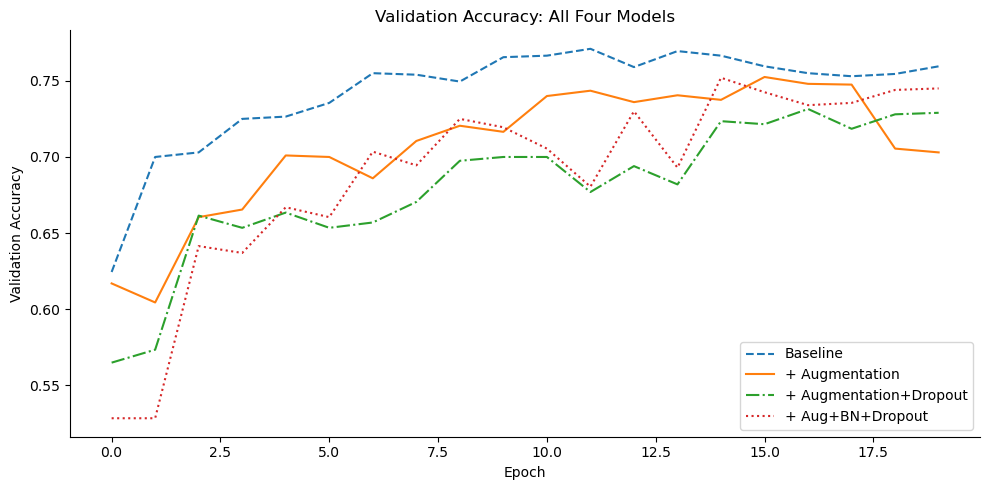

Final validation accuracies (last epoch):
  Baseline:               0.760
  + Augmentation:         0.703
  + Aug + Dropout:        0.729
  + Aug + BN + Dropout:   0.745


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history_baseline.history['val_accuracy'], label='Baseline',               linestyle='--')
ax.plot(history_aug.history['val_accuracy'],      label='+ Augmentation',         linestyle='-')
ax.plot(history_dropout.history['val_accuracy'],  label='+ Augmentation+Dropout', linestyle='-.')
ax.plot(history_bn.history['val_accuracy'],       label='+ Aug+BN+Dropout',       linestyle=':')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Validation Accuracy: All Four Models')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Final validation accuracies (last epoch):")
print(f"  Baseline:               {history_baseline.history['val_accuracy'][-1]:.3f}")
print(f"  + Augmentation:         {history_aug.history['val_accuracy'][-1]:.3f}")
print(f"  + Aug + Dropout:        {history_dropout.history['val_accuracy'][-1]:.3f}")
print(f"  + Aug + BN + Dropout:   {history_bn.history['val_accuracy'][-1]:.3f}")

---
# Part 7 — Reflection (Model Answers)

**1. Which model shows the most overfitting?**  
The **Baseline** model overfits the most. The training accuracy climbs steeply while the validation accuracy plateaus and the loss diverges — a classic overfitting signature.

**2. Did augmentation alone help?**  
Yes. By exposing the model to rotated, shifted, and flipped versions of the training images, augmentation makes it harder to memorize exact pixel patterns. The train/val accuracy gap is visibly reduced.

**3. What effect did Dropout have?**  
Dropout lowers training accuracy (the network is harder to train) but improves or stabilizes validation accuracy. The training curve becomes noisier but the val curve is smoother and higher than the baseline.

**4. Does BatchNorm speed up training?**  
Yes — the model with BatchNorm typically reaches a comparable or better validation accuracy in fewer epochs because the normalized inputs allow the optimizer to find good weights faster.

**5. Which model would you deploy?**  
The **Aug + BN + Dropout** model: it has the best generalization, most stable training, and all techniques are complementary with no significant cost at inference time.

**6. Bonus — 10-class CIFAR-10**  
Changes needed:
- Output layer: `Dense(10, activation='softmax')` instead of `Dense(1, activation='sigmoid')`
- Loss: `categorical_crossentropy` instead of `binary_crossentropy`
- Labels: one-hot encode with `to_categorical(y, 10)` instead of binary 0/1

```python
# Output layer
Dense(10, activation='softmax')

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Labels
y_train_cat = to_categorical(y_train_all, 10)
y_test_cat  = to_categorical(y_test_all,  10)
```